# PyTorch Transformations / PyTorch 数据转换

This demo covers Tranformations using PyTorch when dealing with image data.

本演示涵盖了在处理图像数据时使用 PyTorch 进行的数据转换操作。

### Why Transformations Review / 为什么需要数据转换

In PyTorch, **transforms** are primarily used for **data preprocessing** and **augmentation**. They are essential in preparing data for deep learning models by applying various operations to the dataset, which can improve the efficiency and performance of a model. PyTorch's `torchvision.transforms` module provides a convenient way to apply these operations on image data.

在 PyTorch 中，**transforms（数据转换）** 主要用于 **数据预处理** 和 **数据增强**。它们通过对数据集应用各种操作来为深度学习模型准备数据，这可以提高模型的效率和性能。PyTorch 的 `torchvision.transforms` 模块提供了一种方便的方法来对图像数据应用这些操作。

Here's why PyTorch transforms are important:

以下是 PyTorch 转换的重要性：

### 1. **Data Preprocessing / 数据预处理**
Transforms help convert raw data (e.g., images) into a format that can be fed into a model. For instance, images need to be converted to PyTorch tensors, resized to the required dimensions, or normalized to a certain range of values.

转换有助于将原始数据（例如图像）转换为可以输入到模型中的格式。例如，图像需要转换为 PyTorch 张量、调整大小到所需尺寸或规范化到特定值范围。

### 2. **Data Augmentation / 数据增强**
Data augmentation helps improve the model's generalization by artificially increasing the size of the training dataset. By applying random transformations (like flipping, rotating, or cropping), models can learn to generalize better and avoid overfitting.

数据增强通过人工增加训练数据集的大小来帮助改进模型的泛化能力。通过应用随机转换（如翻转、旋转或裁剪），模型可以学会更好地泛化并避免过拟合。

### 3. **Improve Model Accuracy / 提高模型准确率**
By augmenting the data with random transformations, the model becomes more robust to variations in the input data. For example, a model trained on both original and rotated images can handle different orientations of objects during inference.

通过使用随机转换增强数据，模型对输入数据的变化变得更加稳健。例如，在原始图像和旋转图像上训练的模型在推理期间可以处理对象的不同方向。

### 4. **Pipelines / 流水线处理**
Transforms can be easily chained together using `transforms.Compose()`. This allows for a flexible, reusable pipeline where multiple transformations are applied in sequence. For instance, you can resize an image, convert it to a tensor, and then normalize it with one `Compose` call.

转换可以使用 `transforms.Compose()` 轻松链接在一起。这允许一个灵活的、可重用的流水线，其中多个转换按顺序应用。例如，你可以在一个 `Compose` 调用中调整图像大小、将其转换为张量，然后规范化它。

### Conclusion / 总结
PyTorch transforms simplify preprocessing data to the right format for the model, augmenting data to create diversity in training, and improving model robustness. They simplify the data preparation process and are essential tools in computer vision tasks.

PyTorch 转换简化了为模型预处理数据到正确格式的过程，通过增强数据来创建训练的多样性，并改进模型的稳健性。它们简化了数据准备过程，是计算机视觉任务中的重要工具。

#### NOTE:
The ones you see here are ones that could potentially be good for building image classification models.

以下展示的是可能对构建图像分类模型有用的转换方法。

Please be sure to try some out on your own and/or read the documentation for other available transformations.

请务必自己尝试一些，或阅读其他可用转换的文档。

https://pytorch.org/vision/stable/transforms.html#v2-api-reference-recommended

In [1]:
# helper function / 辅助函数
import matplotlib.pyplot as plt

def display_images(original_image, new_image=None, new_image_name=None):
    """
    Helper function to display to images / 显示两张图像的辅助函数
    """
    if new_image is not None:
        # Create a figure with 1 row and 2 columns / 创建1行2列的图表
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        # Display the original image / 显示原始图像
        axes[0].imshow(original_image)
        axes[0].axis('on')  # Turn off the axis for cleaner display / 打开轴以清晰显示
        axes[0].set_title('Original Image')
        # Display the new image / 显示新图像
        axes[1].imshow(new_image)
        axes[1].axis('on')  # Turn off the axis for cleaner display / 打开轴以清晰显示
        axes[1].set_title(new_image_name)
    else:
        # Create a single row figure / 创建单行图表
        fig = plt.figure(figsize=(10, 5))
        # Display only a single image / 只显示一张图像
        plt.imshow(original_image)
        plt.axis('on')

    # Show the plot / 显示图表
    plt.show()

# Getting started with Transformations / 开始使用数据转换

In [2]:
# Import v2 of transforms
from torchvision.transforms import v2

In [3]:
# Import v1 of transforms
from torchvision import transforms

In [4]:
# Define an image
from PIL import Image

original_image = Image.open('images/cat/cat-1.jpg')
print(original_image)


<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=224x224 at 0x1F6708CAD90>


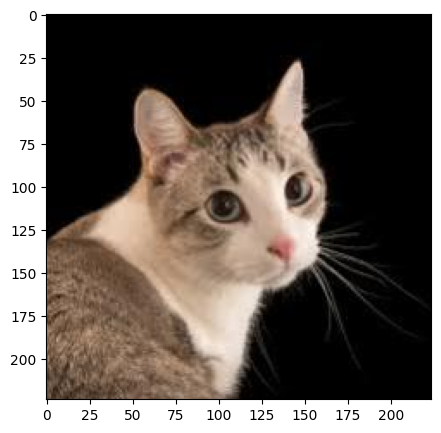

In [5]:
# Show image using our helper function
display_images(original_image=original_image)

### Resize() / 调整大小
Resize an image in pixels. This would ensure that all images are being presented in the same size.

按像素调整图像大小。这可确保所有图像都以相同的大小呈现。

In [6]:
# Using the Resize the image to 50 x 25 pixels using Resize() / 使用 Resize() 将图像调整为 50 x 25 像素
resize_transform = v2.Resize((50, 25))
# Transform it / 进行转换
resized_image = resize_transform(original_image)

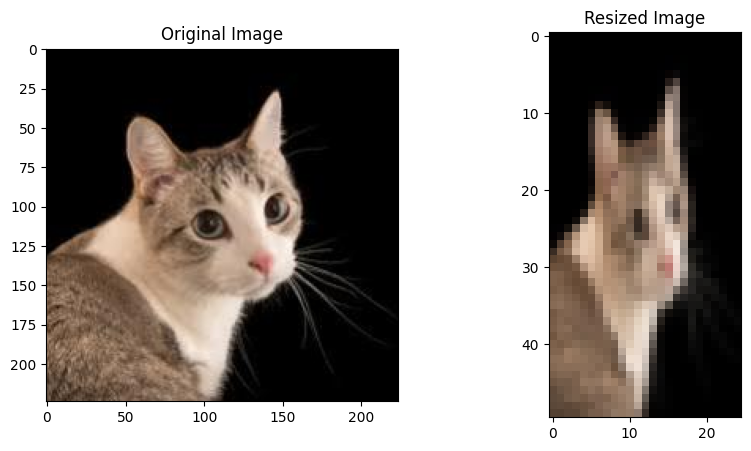

In [7]:
# Show new image resize
display_images(original_image=original_image, new_image=resized_image, new_image_name="Resized Image")

In [8]:
# Lets try again with v1 / 让我们用 v1 再试一次

## RandomHorizontalFlip() / 随机水平翻转
Horizontally flip the input with a given probability.

以给定的概率水平翻转输入图像。

In [9]:
# Set a Random Horizontal Flip augmentation to a probability of 1 (100%) / 设置随机水平翻转增强概率为 1（100%）
rhf_transform = v2.RandomHorizontalFlip(p=1)
# Tranform it / 进行转换
rhf_image = rhf_transform(original_image)

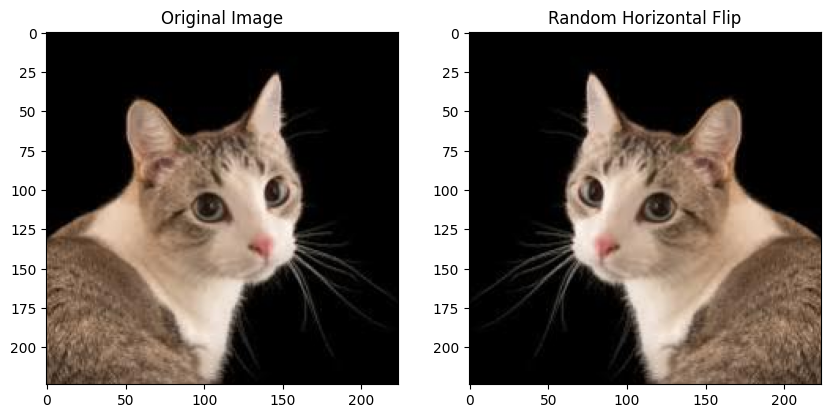

In [10]:
# View the transform
display_images(original_image=original_image, new_image=rhf_image, new_image_name="Random Horizontal Flip")

## ToTensor() / 转换为张量
Simply transform an image into a Tensor. This is necessary format for training a PyTorch model.

将图像简单地转换为张量。这是训练 PyTorch 模型所必需的格式。

In [11]:
# Create transformation using ToTensor() / 使用 ToTensor() 创建转换
tensor_tranform = v2.ToTensor()
# Apply it to our original image / 将其应用于我们的原始图像
tensor_image = tensor_tranform(original_image)

c:\Users\LIHAN\miniconda3\envs\final_gpu_env\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [12]:
# Print the original image format and the new
print(f"Original Image: {original_image}")
print(f"Tensor Image: \n{tensor_image}")

Original Image: <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=224x224 at 0x1F6708CAD90>
Tensor Image: 
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.3412, 0.4275, 0.4706,  ..., 0.0000, 0.0000, 0.0000],
         [0.3333, 0.4118, 0.4667,  ..., 0.0000, 0.0000, 0.0000],
         [0.3294, 0.3647, 0.3961,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.2667, 0.3529, 0.3961,  ..., 0.0000, 0.0000, 0.0000],
         [0.2588, 0.3373, 0.3922,  ..., 0.0000, 0.0000, 0.0000],
         [0.2549, 0.2902, 0.3216,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0

## Normalize() / 规范化
Normalize a tensor image or video with mean and standard deviation.

使用均值和标准差对张量图像或视频进行规范化。

**NOTE**: This will NOT work on a PIL image (original_image). It must be in a tensor format.

**注意**：这不适用于 PIL 图像（original_image）。它必须是张量格式。

In [13]:
# Using our tensor image above, lets normalize it / 使用我们上面的张量图像，让我们对其进行规范化
normalize_transform = v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
# Apply using the tensor_image above / 使用上面的 tensor_image 应用
normalized_image = normalize_transform(tensor_image)

In [14]:
# Print the normalized tensor and the original tensor / 打印规范化张量和原始张量
print(normalized_image)
print(tensor_image)

tensor([[[-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
         ...,
         [-0.3176, -0.1451, -0.0588,  ..., -1.0000, -1.0000, -1.0000],
         [-0.3333, -0.1765, -0.0667,  ..., -1.0000, -1.0000, -1.0000],
         [-0.3412, -0.2706, -0.2078,  ..., -1.0000, -1.0000, -1.0000]],

        [[-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
         ...,
         [-0.4667, -0.2941, -0.2078,  ..., -1.0000, -1.0000, -1.0000],
         [-0.4824, -0.3255, -0.2157,  ..., -1.0000, -1.0000, -1.0000],
         [-0.4902, -0.4196, -0.3569,  ..., -1.0000, -1.0000, -1.0000]],

        [[-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000,  ..., -1

#### What just happened? / 刚才发生了什么？

The pixel values of images are typically in the range [0, 1] if they are converted to tensors using ToTensor() or [0, 255] in their raw form. This normalization effectively scales these values into a range centered around zero.

图像的像素值通常在 [0, 1] 范围内，如果使用 ToTensor() 转换为张量，或在原始形式中为 [0, 255]。此规范化有效地将这些值缩放到以零为中心的范围内。

This will:

这样做会：

    Subtract 0.5 from each pixel value, making the range roughly centered around zero.
    减去 0.5，使范围大致以零为中心。
    
    Divide by 0.5, which scales the pixel values to a range of [-1, 1].
    除以 0.5，将像素值缩放到 [-1, 1] 范围。

#### Why normalize to this range? / 为什么规范化到这个范围？

Normalizing the pixel values to a standard range like [-1, 1] (or another centered range) helps deep learning models learn more efficiently because it standardizes the input data. It often leads to faster convergence and improved model performance.

将像素值规范化到标准范围（如 [-1, 1] 或其他居中范围）有助于深度学习模型更有效地学习，因为它使输入数据标准化。它通常导致更快的收敛和改进的模型性能。

#### Tuples explained / 元组说明
The first tuple (0.5, 0.5, 0.5) represents the mean values for each RGB channel.

第一个元组 (0.5, 0.5, 0.5) 表示每个 RGB 通道的均值。

The second tuple (0.5, 0.5, 0.5) represents the standard deviation values for each RGB channel.

第二个元组 (0.5, 0.5, 0.5) 表示每个 RGB 通道的标准差值。

## RandomCrop() / 随机裁剪
Crop the input at a random location. This is not a probability but random location.

在随机位置裁剪输入。这不是概率，而是随机位置。

In [25]:
# Randomly crop the image at a random location / 在随机位置随机裁剪图像
rc_transform = v2.RandomCrop(size=(100, 100))
# Run the random crop / 运行随机裁剪
rc_image = rc_transform(original_image)

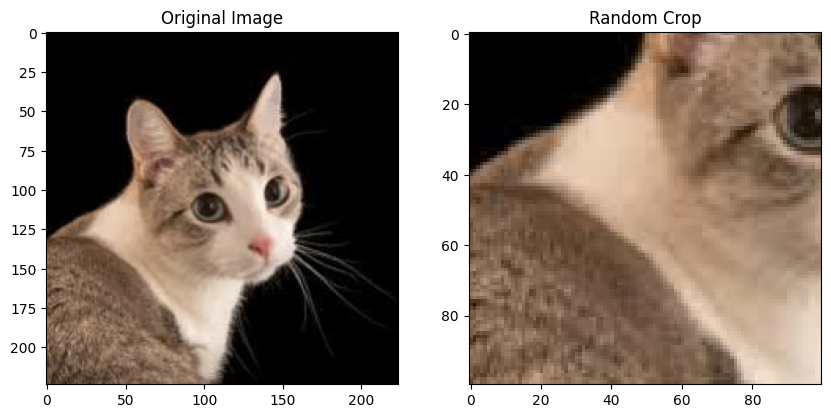

In [26]:
# View the transform
display_images(original_image=original_image, new_image=rc_image, new_image_name="Random Crop")

In [19]:
# NOTE: Run it a couple of times to see that it changes locations each time. / 注意：运行几次查看每次是否改变位置。

## RandomPhotometricDistort() / 随机光度失真
Randomly distorts the image or video. Adjust the contrast, saturation, hue, brightness, and also randomly permutes channels.

随机扭曲图像或视频。调整对比度、饱和度、色调、亮度，并随机改变通道顺序。

In [29]:
# Create the Distort. Notice the different settings. / 创建失真。注意不同的设置。
rpd_transform = v2.RandomPhotometricDistort(
    brightness=(0.875, 1.125), 
    contrast=(0.5, 1.5), 
    saturation=(0.5, 1.5),
    hue=(- 0.05, 0.05), 
    p=1
)

# Create the augmentation / 创建增强
rpd_image = rpd_transform(original_image)

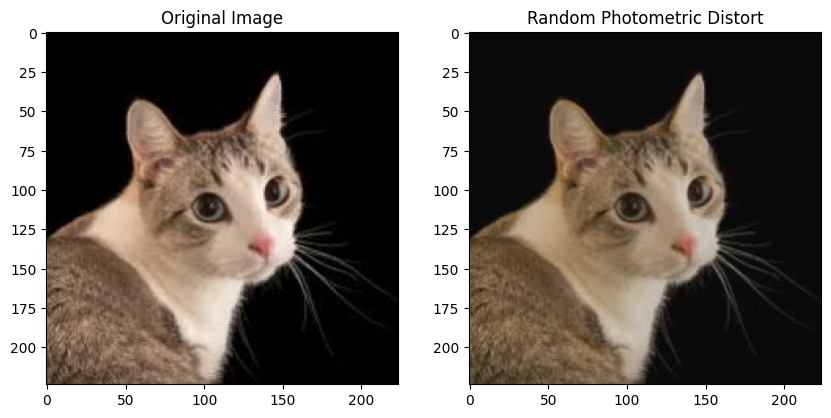

In [30]:
# View the differences
display_images(original_image=original_image, new_image=rpd_image, new_image_name="Random Photometric Distort")

In [31]:
# NOTE: Run it several times to see the difference. / 注意：运行几次查看差异。

## RandomResize() / 随机调整大小
Randomly resize the input. This may or may not be a good option keep in mind.

随机调整输入大小。请记住，这可能是也可能不是一个好选择。

In [34]:
# Create transform / 创建转换
rr_transform = v2.RandomResize(min_size=100, max_size=200)
# Apply the augmentation / 应用增强
rr_image = rr_transform(original_image)

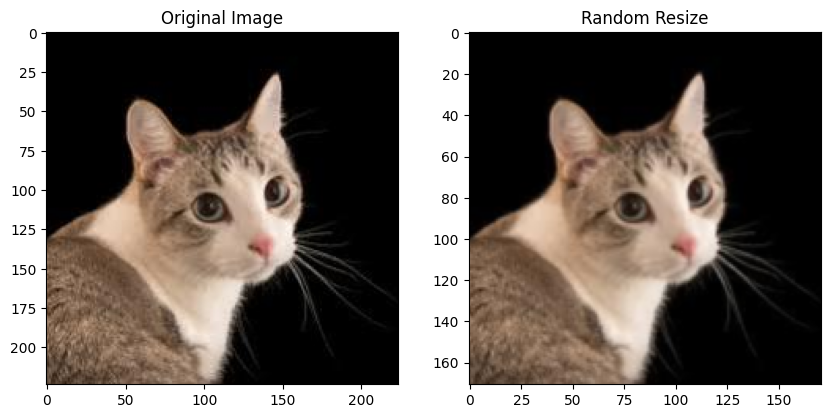

In [35]:
# View the differences
display_images(original_image=original_image, new_image=rr_image, new_image_name="Random Resize")

# Pipelines with Compose() / 使用 Compose() 构建流水线
Compose() allows for use to build a pipeline of transformations on images.

Compose() 允许我们构建一个图像转换流水线。

In [39]:
# Lets build a pipeline using the above transformations. We define this in a list. / 让我们使用上述转换构建流水线。我们在列表中定义它。
transforms_pipeline = v2.Compose([
    v2.RandomCrop(size=(100, 100)),
    v2.RandomPhotometricDistort(
        brightness=(0.875, 1.125), 
        contrast=(0.5, 1.5), 
        saturation=(0.5, 1.5),
        hue=(- 0.05, 0.05), 
        p=1),
    v2.RandomResize(min_size=75, max_size=150),
    v2.RandomHorizontalFlip(p=1)
])

In [40]:
# Apply the pipeline to our original image / 将流水线应用于我们的原始图像
pipeline_image = transforms_pipeline(original_image)

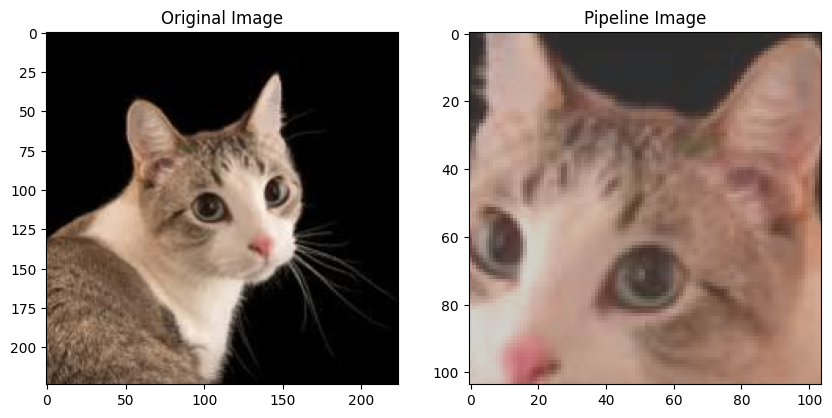

In [41]:
# View the original to the new / 查看原始到新的对比
display_images(original_image=original_image, new_image=pipeline_image, new_image_name="Pipeline Image")

# Integrating with Datasets / 与数据集集成
Lets load the FashionMNIST preloaded Dataset from the previous section and see how we can apply our transform pipeline to those images.

加载之前章节中的 FashionMNIST 预加载数据集，并查看如何将我们的转换流水线应用于这些图像。

In [42]:
# Import the torchvision datasets library
import torchvision.datasets

In [43]:
# Create a dataset first without our pipeline
original_image_dataset = torchvision.datasets.FashionMNIST(root='./fashion', train=False, download=True)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.4MB/s]


Extracting ./fashion\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./fashion\FashionMNIST\raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 331kB/s]


Extracting ./fashion\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./fashion\FashionMNIST\raw



100%|██████████| 4.42M/4.42M [00:00<00:00, 6.04MB/s]


Extracting ./fashion\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./fashion\FashionMNIST\raw



100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]

Extracting ./fashion\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./fashion\FashionMNIST\raw



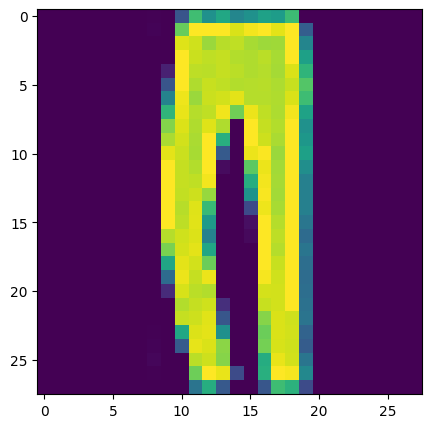

In [44]:
# Get an image from the dataset / 从数据集中获取图像
original_image, label = original_image_dataset[2]
# View it / 查看它
display_images(original_image=original_image)

In [45]:
# Create a new pipeline to fit the dataset / 创建适合数据集的新流水线
transforms_pipeline = v2.Compose([
    v2.RandomCrop(size=(15, 15)), # Adjust the crop to fit the image size / 调整裁剪以适应图像大小
    v2.RandomPhotometricDistort(
        brightness=(0.875, 1.125), 
        contrast=(0.5, 1.5), 
        saturation=(0.5, 1.5),
        hue=(- 0.05, 0.05), 
        p=1),
    v2.RandomResize(min_size=10, max_size=15), # Adjust the crop to fit the image size / 调整裁剪以适应图像大小
    v2.RandomHorizontalFlip(p=1)
])

In [46]:
# Create a new datset with our pipeline / 用我们的流水线创建新数据集
pipeline_image_dataset = torchvision.datasets.FashionMNIST(root='./fashion', train=False, download=True, 
                                                           transform=transforms_pipeline)

In [49]:
# Get the same image from above but from the new dataset / 从新数据集中获取与上面相同的图像
pipeline_image, label = pipeline_image_dataset[2]

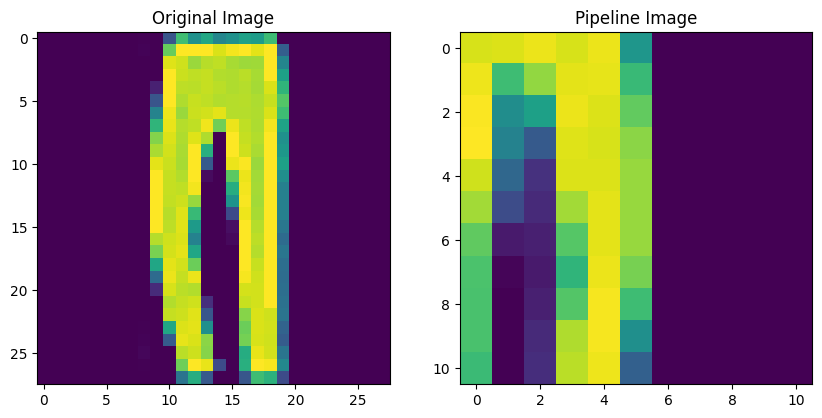

In [50]:
# View the images together / 并排查看图像
display_images(original_image=original_image, new_image=pipeline_image, new_image_name="Pipeline Image")